# Couche 2 : détection d'anomalies (IA-5)
**CyberGuardian AI**, notebook de validation de la Couche 2

---

### Ce que demande la spécification

> **IA-5 · Couche 2, détection d'anomalies (P1, inchangé)**
> Isolation Forest entraîné sur le **trafic légitime simulé**, plus **z-scores par abonné en garde-fou interprétable**.
> Modèle **sérialisé versionné dans S3 `models/`**.

### Ce que fait ce notebook
Il vérifie **chacune des trois exigences** avec des contrôles automatiques, puis mesure les performances
**en temps réel**, c'est-à-dire transaction par transaction, comme en production.
On peut l'exécuter de haut en bas (*Run All*) sans infrastructure : Kafka, Redis et MinIO sont optionnels.

| # | Exigence | Où la vérifier | Contrôle automatique |
|---|---|---|---|
| 1 | Isolation Forest entraîné sur le trafic **légitime** simulé | Sections 2 et 3 | le train ne contient que du trafic `NORMAL` non frauduleux ; aucun abonné partagé entre train / validation / test ; réglage sur la validation, jamais sur le test |
| 2 | **z-scores par abonné** en garde-fou **interprétable** | Section 7 | chaque transaction reçoit ses z-scores et des raisons lisibles ; le garde-fou relève le score quand un z-score est extrême |
| 3 | Modèle **sérialisé et versionné** dans S3 `models/` | Section 4 | fichier `.pkl` horodaté + métriques + pointeur `production/current.json`, rechargé par le détecteur |

La **section 9** récapitule tout sous forme de verdict ✅ / ❌.

### Petit lexique

| Terme | Signification |
|---|---|
| **Isolation Forest (IF)** | Modèle *non supervisé* : il apprend à quoi ressemble le trafic normal et repère ce qui s'en écarte. Il n'a jamais vu de fraude pendant l'entraînement. |
| **Score Couche 2 (0-100)** | 0 = parfaitement habituel, 100 = extrêmement anormal. Un score de 50 signifie « plus anormal que 95 % du trafic légitime d'entraînement ». |
| **z-score par abonné** | Nombre d'écarts-types entre la transaction et **les habitudes de cet abonné**. z = +6 sur le montant : « montant 6 fois plus éloigné de sa moyenne que d'habitude ». |
| **Garde-fou** | Si un z-score dépasse **5σ**, le score est relevé à **50** au minimum (zone *CHALLENGE* = vérification OTP), même si l'IF n'a rien vu. |
| **Séparation** | Score moyen des fraudes − score moyen des légitimes. Sur une échelle 0-100, l'écart se lit en % : 0 % = aucune distinction, 100 % = séparation parfaite. |
| **Rappel (recall)** | Part des fraudes détectées. |
| **FPR (taux de faux positifs)** | Part des transactions légitimes signalées à tort. |
| **Précision** | Parmi les alertes, part de vraies fraudes. |
| **AUC-PR** | Qualité globale du classement fraude/légitime sur des classes déséquilibrées. Un modèle aléatoire obtient le taux de fraude (≈ 0,03). |
| **Rappel à 1 % de FPR** | Part des fraudes détectées si l'on accepte 1 % de fausses alertes. C'est la métrique de réglage. |

> ## ⚠️ Volume de simulation : 1 500 abonnés par défaut
> Ce notebook simule **1 500 abonnés** (paramètre `NB_ABONNES_SIMULES`, section 0), soit environ 120 à 180 fraudes dans le jeu de test.
> **Ne pas descendre à 500** pour juger les performances : avec seulement ~50 fraudes de test, dont 1 à 5 attaques
> discrètes ou vols de téléphone (les cas les plus difficiles), les résultats sont **nettement trop optimistes**
> (par exemple AUC-PR de la Couche 3 : 0,875 à 500 abonnés contre 0,741 à 1 500).
>
> **Toujours lancer avec *Kernel → Restart Kernel and Run All Cells*** : sans redémarrage, un ancien simulateur resté
> en mémoire serait utilisé. La cellule de configuration vérifie le volume réellement appliqué et s'arrête sinon.
> Durée : environ 3 à 5 minutes.

### Où se situe la Couche 2 dans le pipeline

```
Transaction ─► profil abonné (Redis) ─► compute_features()
                                             │
          ┌──────────────────────────────────┼───────────────────────────┐
          ▼                                  ▼                           ▼
   Couche 1 : règles              COUCHE 2 (ce notebook)          Couche 3 : XGBoost
                                  ┌───────────────────────┐
                                  │ Isolation Forest       │──► score_if (0-100)
                                  │ z-scores par abonné    │──► raisons lisibles
                                  │ garde-fou (z ≥ 5σ)     │──► score = max(score_if, 50)
                                  └───────────────────────┘
                                             ▼
                              fusion ─► PASS (<30) / CHALLENGE (30-70) / BLOCK (≥70)
```

Code source : `engine/anomaly/` (`dataset.py`, `train.py`, `detector.py`, `zscores.py`).

---
## 0. Configuration

Deux paramètres à régler au besoin :
- `NB_ABONNES_SIMULES` : **1 500** (chiffres de référence ; 500 donne des résultats trop optimistes).
- `SOURCE_DONNEES` : `"simulateur"` (par défaut, reproductible, sans infrastructure) ou `"kafka"` (vide les topics Redpanda).
- `PUBLIER_MINIO` : `True` pour publier aussi le modèle dans le vrai MinIO (`docker compose up minio`).

In [1]:
SOURCE_DONNEES = "simulateur"   # "simulateur" | "kafka"
PUBLIER_MINIO  = False          # True = publier aussi le modèle dans MinIO

import sys, os, json, pickle, time, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, "..")
# Volume de simulation : 1 500 abonnés = chiffres de référence (500 = trop optimiste, voir l'avertissement)
NB_ABONNES_SIMULES = 1500
os.environ["SIM_NB_ABONNES"] = str(NB_ABONNES_SIMULES)   # lu par simulator/config.py à son import
os.environ.update({
    "REDIS_HOST": "localhost", "REDIS_PORT": "16379",
    "MINIO_ENDPOINT": "localhost:19000",
    "MINIO_ACCESS_KEY": "minioadmin", "MINIO_SECRET_KEY": "minioadmin123",
})

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from IPython.display import display, Markdown
from sklearn.metrics import (average_precision_score, roc_auc_score,
                             precision_recall_curve, roc_curve)

from simulator.subscribers import generate_subscribers
from simulator.calendrier  import planifier_simulation
from simulator.config      import SEED, NB_ABONNES
assert NB_ABONNES == NB_ABONNES_SIMULES, (
    f"Le simulateur est chargé avec {NB_ABONNES} abonnés au lieu de {NB_ABONNES_SIMULES} : "
    "faire Kernel → Restart Kernel and Run All Cells")
from simulator.profiles    import build_initial_profile
from engine.anomaly.dataset  import build_dataset, FEATURE_NAMES
from engine.anomaly.train    import train
from engine.anomaly.detector import (AnomalyDetector, Z_OVERRIDE_SOFT, Z_OVERRIDE_HARD,
                                     Z_MIN_TRANSACTIONS, Z_GUARD_FLOOR, Z_GUARD_ENABLED)
from engine.features.updater import apply_transaction, apply_sim_event, apply_otp_event
from interfaces.store import ObjectStore, BUCKET_MODELS

pd.set_option("display.max_colwidth", 120)
print(f"Features IF ({len(FEATURE_NAMES)}) : {FEATURE_NAMES}")
print(f"Garde-fou z-score : actif={Z_GUARD_ENABLED} | alerte ≥ {Z_OVERRIDE_SOFT}σ | "
      f"plancher {Z_GUARD_FLOOR:.0f} si ≥ {Z_OVERRIDE_HARD}σ | historique min {Z_MIN_TRANSACTIONS} tx")

Features IF (16) : ['nb_tx_1h', 'new_device', 'amount_ratio', 'nb_tx_7j', 'is_roaming', 'ecart_type_montant', 'zscore_montant', 'hours_since_sim_swap', 'otp_count_1h', 'new_beneficiary', 'nb_beneficiaires_1h', 'nb_swaps_30j', 'nb_tx_24h', 'nb_otp_24h', 'nb_tx_depuis_swap', 'montant_cumule_depuis_swap']
Garde-fou z-score : actif=True | alerte ≥ 3.0σ | plancher 50 si ≥ 5.0σ | historique min 10 tx


In [2]:
# ── Outils communs au notebook ──────────────────────────────────────
COULEUR = {"Légitime": "#2a78d6", "Fraude": "#eb6834"}
SEUIL_ALERTE, SEUIL_PASS, SEUIL_BLOCK = 50, 30, 70

def rappel_a_fpr(y, s, fpr_cible):
    fpr, tpr, _ = roc_curve(y, s)
    m = fpr <= fpr_cible
    return float(tpr[m].max()) if m.any() else 0.0

def metriques(y, s):
    # Métriques principales pour des labels y et des scores s (0-100).
    y, s = np.asarray(y), np.asarray(s, dtype=float)
    p = s >= SEUIL_ALERTE
    tp, fp = int((p & (y == 1)).sum()), int((p & (y == 0)).sum())
    return {
        "AUC-PR": average_precision_score(y, s),
        "ROC-AUC": roc_auc_score(y, s),
        "Rappel @1% FPR": rappel_a_fpr(y, s, 0.01),
        "Rappel @5% FPR": rappel_a_fpr(y, s, 0.05),
        f"Rappel @ seuil {SEUIL_ALERTE}": tp / max(int((y == 1).sum()), 1),
        f"FPR @ seuil {SEUIL_ALERTE}": fp / max(int((y == 0).sum()), 1),
        f"Précision @ seuil {SEUIL_ALERTE}": tp / max(tp + fp, 1),
        "Score moyen fraudes": float(s[y == 1].mean()),
        "Score moyen légitimes": float(s[y == 0].mean()),
        "Séparation (pts)": float(s[y == 1].mean() - s[y == 0].mean()),
    }

def tableau_metriques(met, y):
    # Tableau lisible : valeur formatée + comment la lire.
    pct = lambda v: f"{v:.1%}"
    lignes = [
        ("Séparation fraudes / légitimes", f"{met['Séparation (pts)']:.1f} %",
         f"fraudes {met['Score moyen fraudes']:.1f} vs légitimes {met['Score moyen légitimes']:.1f} (sur 100) ; ≥ 20 % = bonne"),
        ("AUC-PR", f"{met['AUC-PR']:.3f}", f"aléatoire = {np.mean(y):.3f} ; plus c'est haut, mieux c'est (max 1)"),
        ("ROC-AUC", f"{met['ROC-AUC']:.3f}", "0,5 = aléatoire, 1 = parfait"),
        ("Rappel @1% FPR", pct(met["Rappel @1% FPR"]), "fraudes détectées si on tolère 1 % de fausses alertes"),
        ("Rappel @5% FPR", pct(met["Rappel @5% FPR"]), "fraudes détectées si on tolère 5 % de fausses alertes"),
        (f"Rappel @ seuil {SEUIL_ALERTE}", pct(met[f"Rappel @ seuil {SEUIL_ALERTE}"]), "fraudes détectées au seuil d'alerte 50"),
        (f"FPR @ seuil {SEUIL_ALERTE}", pct(met[f"FPR @ seuil {SEUIL_ALERTE}"]), "légitimes signalés à tort au seuil 50"),
        (f"Précision @ seuil {SEUIL_ALERTE}", pct(met[f"Précision @ seuil {SEUIL_ALERTE}"]), "part de vraies fraudes parmi les alertes au seuil 50"),
    ]
    return pd.DataFrame(lignes, columns=["indicateur", "valeur", "comment lire"]).set_index("indicateur")

def lecture_metriques(met, y):
    # Interprétation en langage courant, générée à partir des chiffres.
    n_leg = int((np.asarray(y) == 0).sum())
    fp_1000 = met[f"FPR @ seuil {SEUIL_ALERTE}"] * 1000
    alertes_par_fraude = 1 / max(met[f"Précision @ seuil {SEUIL_ALERTE}"], 1e-9)
    return (
        f"**Lecture** :\n"
        f"- **Séparation de {met['Séparation (pts)']:.0f} %** : une fraude obtient en moyenne "
        f"{met['Score moyen fraudes']:.0f}/100, une transaction légitime {met['Score moyen légitimes']:.0f}/100. "
        f"Les deux populations sont nettement distinctes.\n"
        f"- **Classement** : ROC-AUC {met['ROC-AUC']:.2f}. Prise au hasard, une fraude a {met['ROC-AUC']:.0%} de chances "
        f"d'avoir un score plus élevé qu'une transaction légitime. L'AUC-PR ({met['AUC-PR']:.2f}) est "
        f"{met['AUC-PR'] / max(np.mean(y), 1e-9):.0f} fois meilleure que le hasard ({np.mean(y):.3f}).\n"
        f"- **Au seuil 50** : {met[f'Rappel @ seuil {SEUIL_ALERTE}']:.0%} des fraudes sont signalées, "
        f"pour environ {fp_1000:.0f} clients légitimes dérangés sur 1 000. "
        f"Comme les fraudes sont rares (≈ {np.mean(y):.1%} des transactions), cela donne environ "
        f"**{alertes_par_fraude:.0f} alertes pour 1 vraie fraude** (précision {met[f'Précision @ seuil {SEUIL_ALERTE}']:.0%}).\n"
        f"- **Si l'on veut très peu de fausses alertes (1 %)**, on ne détecte plus que {met['Rappel @1% FPR']:.0%} des fraudes.\n\n"
        f"C'est le profil attendu d'une couche **non supervisée** : très bonne pour signaler l'inhabituel, "
        f"trop peu précise pour bloquer seule. Elle sert de filet et d'explication, la Couche 3 (XGBoost) apporte la précision."
    )

def tableau_seuils(y, s, seuils=(30, 40, 50, 60, 70, 80, 90)):
    y, s = np.asarray(y), np.asarray(s, dtype=float)
    lignes = []
    for t in seuils:
        p = s >= t
        tp, fp = int((p & (y == 1)).sum()), int((p & (y == 0)).sum())
        fn = int((y == 1).sum()) - tp
        lignes.append({"Seuil": t, "Fraudes détectées (TP)": tp, "Fraudes manquées (FN)": fn,
                       "Fausses alertes (FP)": fp,
                       "Rappel": f"{tp / max(tp + fn, 1):.1%}",
                       "FPR": f"{fp / max(int((y == 0).sum()), 1):.2%}",
                       "Précision": f"{tp / max(tp + fp, 1):.1%}"})
    return pd.DataFrame(lignes).set_index("Seuil")

def histo_scores(y, s, titre):
    fig = go.Figure()
    for lab, nom in [(0, "Légitime"), (1, "Fraude")]:
        fig.add_histogram(x=np.asarray(s)[np.asarray(y) == lab], name=nom,
                          histnorm="percent", xbins=dict(start=0, end=101, size=5),
                          marker=dict(color=COULEUR[nom], line=dict(color="white", width=1)),
                          opacity=0.75)
    fig.add_vline(x=SEUIL_ALERTE, line_dash="dash", line_color="#52514e",
                  annotation_text=f"seuil {SEUIL_ALERTE}")
    fig.update_layout(barmode="overlay", title=titre, height=380, template="plotly_white",
                      xaxis_title="Score Couche 2 (0-100)",
                      yaxis_title="% des transactions de la classe")
    fig.show()

class MemStore(ObjectStore):
    # Stockage objet en mémoire : même interface que MinIO/S3 (upload/download).
    def __init__(self): self._d = {}
    def upload(self, b, k, data): self._d[f"{b}/{k}"] = data
    def download(self, b, k):
        if f"{b}/{k}" not in self._d: raise KeyError(f"{b}/{k}")
        return self._d[f"{b}/{k}"]
    def exists(self, b, k): return f"{b}/{k}" in self._d
    def keys(self): return sorted(self._d)

print("Outils prêts")

Outils prêts


---
## 1. Données : le trafic simulé

Le simulateur produit 30 jours d'activité pour `NB_ABONNES_SIMULES` abonnés (1 500 par défaut) sur **trois flux** :
- `transactions` : les paiements et transferts (avec `label_fraude` et `type_scenario`) ;
- `sim-events` : les changements de carte SIM (*SIM swap*) ;
- `otp-events` : les codes OTP envoyés.

Les trois flux sont nécessaires. Sans `sim-events` ni `otp-events`, les features de swap SIM et d'OTP resteraient constantes.

In [3]:
all_events = []
if SOURCE_DONNEES == "kafka":
    try:
        from interfaces.streams import get_consumer
        for topic in ["transactions", "sim-events", "otp-events"]:
            c = get_consumer(group_id=f"nb-if-{topic}", topic=topic)
            batch = c.drain(stream=topic, timeout_ms=3000, max_empty_polls=3)
            c.close()
            all_events += [{**ev, "stream": topic} for ev in batch]
        if not all_events:
            raise ValueError("topics vides")
    except Exception as e:
        print(f"Kafka indisponible ({e}) → bascule sur le simulateur")
        all_events = []

comptes = generate_subscribers(NB_ABONNES, seed=SEED)
# Profils initiaux : ce que Redis contient au démarrage (simulator/profiles.py).
# Construits AVANT la simulation, comme simulator/main.py : la simulation modifie les
# comptes (nouveau téléphone, solde…) et les lire après serait une fuite du futur.
profils_initiaux = {c.id_compte: build_initial_profile(c) for c in comptes}
if not all_events:
    SOURCE_DONNEES = "simulateur"
    scenarios  = planifier_simulation(comptes, seed=SEED)
    all_events = [{**e.payload, "stream": e.stream} for sc in scenarios for e in sc.evenements]

nom_scenario = lambda x: getattr(x, "value", x)   # TypeScenario.NORMAL → "NORMAL"

df_ev = pd.DataFrame(all_events)
print(f"Source : {SOURCE_DONNEES} | {NB_ABONNES} abonnés | {len(all_events)} événements")
display(df_ev["stream"].value_counts().rename("nb événements").to_frame())

df_tx = df_ev[df_ev["stream"] == "transactions"].copy()
df_tx["type_scenario"] = df_tx["type_scenario"].map(nom_scenario)
print("Transactions par scénario simulé :")
display(pd.crosstab(df_tx["type_scenario"], df_tx["label_fraude"].map({0: "Légitime", 1: "Fraude"}),
                    margins=True, margins_name="Total"))

Simulation 30 jours planifiée (Évolution chronologique d'état) :
  Scénarios :  80808  (fraudes=362, légitimes=80446)
  Événements: 109538
Source : simulateur | 1500 abonnés | 109538 événements


,nb événements
stream,
transactions,80473
otp-events,28426
sim-events,639


Transactions par scénario simulé :


label_fraude,Fraude,Légitime,Total
type_scenario,,,
GROS_MONTANT_LEGITIME,0,30,30
NORMAL,0,76166,76166
NOUVEAU_DEVICE_LEGITIME,0,75,75
PIC_OTP,34,0,34
SIM_SWAP_CASCADE,419,0,419
SIM_SWAP_DISCRET,41,0,41
SIM_SWAP_SIMPLE,89,0,89
SWAP_LEGITIME,0,616,616
VOL_TELEPHONE,117,0,117


**Lecture** : `NORMAL` est le trafic quotidien ordinaire. Les autres scénarios sont :
- **des fraudes** : `SIM_SWAP_*`, `PIC_OTP`… ;
- **des cas légitimes mais inhabituels** : `SWAP_LEGITIME`, `NOUVEAU_DEVICE_LEGITIME`… Ce sont des sources attendues de fausses alertes.

---
## 2. Construction du dataset (exigence 1)

### Replay chronologique strict
Les événements sont rejoués **dans l'ordre du temps**, en partant des **profils initiaux** que Redis contient au démarrage
(appareil habituel, antenne de domicile, montant moyen habituel). Chaque transaction est décrite avec le profil de l'abonné
**tel qu'il était juste avant elle**, exactement comme en production. Aucune information future n'est utilisée.

### Découpage par abonné (et non par transaction)
```
N abonnés ──mélange (seed 42)──► 70 % TRAIN      │ 10 % VALIDATION         │ 20 % TEST
                                   trafic NORMAL     │ toutes leurs tx         │ toutes leurs tx
                                   non frauduleux    │ → réglage des           │ → mesure finale
                                   → apprentissage   │   hyperparamètres       │   des performances
```
- Un abonné n'apparaît que dans **une seule** partie : le modèle est testé sur des abonnés qu'il n'a jamais vus.
- Les fraudes des abonnés TRAIN ne sont utilisées nulle part.
- La **1ʳᵉ transaction de chaque compte** (aucun historique) est écartée de l'apprentissage. En production, elle reçoit
  directement le score 0, et ses features sont dégénérées (montant de référence inconnu).
- Le **test n'est jamais regardé** avant la section 5.

In [4]:
ds = build_dataset(events=all_events, profiles_override=profils_initiaux)
m = ds.meta

display(pd.DataFrame({
    "Abonnés":      [m["n_subscribers_train"], m["n_subscribers_val"], m["n_subscribers_test"]],
    "Transactions": [ds.n_train, ds.n_val, ds.n_test],
    "dont fraudes": [0, int(ds.y_val.sum()), int(ds.y_test.sum())],
    "Rôle": ["apprentissage (légitime uniquement)", "réglage des hyperparamètres", "mesure finale"],
}, index=["TRAIN", "VALIDATION", "TEST"]))
print(f"Écartés de l'apprentissage : {m['n_fraud_excluded_overlap']} fraudes et "
      f"{m['n_atypical_excluded_overlap']} légitimes atypiques des abonnés train, "
      f"{m['n_sans_historique_exclus']} premières transactions sans historique")

,Abonnés,Transactions,dont fraudes,Rôle
TRAIN,1050,52768,0,apprentissage (légitime uniquement)
VALIDATION,150,7882,61,réglage des hyperparamètres
TEST,300,15630,178,mesure finale


Écartés de l'apprentissage : 461 fraudes et 2583 légitimes atypiques des abonnés train, 1149 premières transactions sans historique


### Contrôles automatiques de l'exigence 1
On recompte **indépendamment**, à partir des événements bruts, ce que le train doit contenir.

In [5]:
train_ids = set(ds.train_subscriber_ids)
val_ids   = set(ds.val_subscriber_ids)
test_ids  = set(ds.test_subscriber_ids)

# rang chronologique de chaque transaction dans son compte (0 = première, sans historique)
rang = df_tx.sort_values("horodatage", kind="stable").groupby("id_compte").cumcount()
df_tx["a_historique"] = rang.reindex(df_tx.index) > 0

attendu_train = int(((df_tx["id_compte"].isin(train_ids))
                     & (df_tx["type_scenario"] == "NORMAL")
                     & (df_tx["label_fraude"] == 0)
                     & df_tx["a_historique"]).sum())
fraudes_train = int(((df_tx["id_compte"].isin(train_ids)) & (df_tx["label_fraude"] == 1)).sum())

CONTROLES = {}   # rempli au fil du notebook, résumé en section 9
CONTROLES["1a. Train = uniquement trafic NORMAL non frauduleux"] = (ds.n_train == attendu_train)
CONTROLES["1b. Aucun abonné partagé entre train / val / test"] = (
    not (train_ids & val_ids) and not (train_ids & test_ids) and not (val_ids & test_ids))
CONTROLES["1c. Validation et test contiennent des fraudes"] = (ds.y_val.sum() > 0 and ds.y_test.sum() > 0)

print(f"Transactions NORMAL/légitimes attendues dans le train : {attendu_train} | obtenues : {ds.n_train}")
print(f"Fraudes des abonnés train (toutes écartées)           : {fraudes_train}")
for k, v in CONTROLES.items():
    print(f"  {'✅' if v else '❌'} {k}")

Transactions NORMAL/légitimes attendues dans le train : 52768 | obtenues : 52768
Fraudes des abonnés train (toutes écartées)           : 461
  ✅ 1a. Train = uniquement trafic NORMAL non frauduleux
  ✅ 1b. Aucun abonné partagé entre train / val / test
  ✅ 1c. Validation et test contiennent des fraudes


### Ce que « voit » l'Isolation Forest sur le trafic légitime
Une feature **constante** dans le train (toujours la même valeur chez les légitimes) ne peut pas servir à l'IF :
il découpe les données entre le minimum et le maximum observés, donc rien à découper.
Ce n'est pas un bug. C'est une limite connue des modèles entraînés sur du trafic normal seul,
et c'est justement le rôle des z-scores (section 7) et des autres couches de compléter.

In [6]:
df_train = pd.DataFrame(ds.X_train, columns=FEATURE_NAMES)
df_testf = pd.DataFrame(ds.X_test,  columns=FEATURE_NAMES)
resume_feat = pd.DataFrame({
    "valeurs distinctes (train)": df_train.nunique(),
    "moyenne légitimes (train)":  df_train.mean().round(3),
    "moyenne fraudes (test)":     df_testf[ds.y_test == 1].mean().round(3),
})
resume_feat["utilisable par l'IF"] = np.where(resume_feat["valeurs distinctes (train)"] > 1, "oui", "non (constante)")
display(resume_feat)

,valeurs distinctes (train),moyenne légitimes (train),moyenne fraudes (test),utilisable par l'IF
nb_tx_1h,8,0.387000,1.197000,oui
new_device,2,0.003000,0.118000,oui
amount_ratio,17488,0.871000,0.741000,oui
nb_tx_7j,59,16.811001,12.303000,oui
is_roaming,1,0.000000,0.539000,non (constante)
ecart_type_montant,51751,30575.195312,24591.890625,oui
zscore_montant,28933,-176.035995,-3939.694092,oui
hours_since_sim_swap,10543,1772.687988,232.014008,oui
otp_count_1h,10,0.425000,1.393000,oui
new_beneficiary,2,0.402000,0.545000,oui


---
## 3. Entraînement de l'Isolation Forest (exigence 1)

Étapes réalisées par `engine/anomaly/train.py` :
1. `RobustScaler` ajusté **sur le train seulement** (met les features à la même échelle, robuste aux valeurs extrêmes).
2. **Réglage** : 12 combinaisons `max_samples × max_features` sont testées. On garde celle qui maximise le
   **rappel à 1 % de FPR sur la VALIDATION**.
3. Entraînement final (300 arbres) sur le train.
4. **Calibration** du score brut en score 0-100, à partir des scores du train :
   médiane → 0, 90ᵉ centile → 30, 95ᵉ → 50, 99ᵉ → 90, 99,9ᵉ → 100.

In [7]:
store = MemStore()
res = train(ds, store=store, promote=True)
mt = res.metrics

print(f"Version du modèle : {res.version}")
print(f"Paramètres retenus : max_samples={mt['if_max_samples']}, max_features={mt['if_max_features']}, "
      f"n_estimators={mt['if_n_estimators']}")
print(f"Rappel @1% FPR sur la validation : {mt['val_recall_at_1pct_fpr']:.1%}")
print("\nEssais du réglage (validation uniquement) :")
display(pd.DataFrame(mt["tuning_trials"])
        .sort_values("val_recall_at_1pct_fpr", ascending=False)
        .rename(columns={"val_recall_at_1pct_fpr": "rappel @1% FPR (val)"})
        .reset_index(drop=True))

Version du modèle : 20260924_143841
Paramètres retenus : max_samples=512, max_features=1.0, n_estimators=300
Rappel @1% FPR sur la validation : 47.5%

Essais du réglage (validation uniquement) :


,max_samples,max_features,rappel @1% FPR (val)
0,512,1.00,0.4754
1,256,1.00,0.4426
2,512,0.60,0.4262
3,512,0.85,0.4098
4,128,1.00,0.3607
5,256,0.85,0.3607
6,512,0.70,0.3607
7,128,0.60,0.3443
8,256,0.60,0.3443
9,128,0.85,0.2951


In [8]:
calib = mt["score_calibration"]["points"]
display(pd.DataFrame({
    "score brut d'anomalie": [round(x, 4) for x, _ in calib],
    "score 0-100": [y for _, y in calib],
    "signification": ["transaction légitime médiane",
                      "plus anormal que 90 % du trafic légitime",
                      "plus anormal que 95 % du trafic légitime",
                      "plus anormal que 99 % du trafic légitime",
                      "plus anormal que 99,9 % du trafic légitime"],
}))

,score brut d'anomalie,score 0-100,signification
0,0.3944,0,transaction légitime médiane
1,0.4944,30,plus anormal que 90 % du trafic légitime
2,0.5284,50,plus anormal que 95 % du trafic légitime
3,0.5992,90,plus anormal que 99 % du trafic légitime
4,0.6687,100,"plus anormal que 99,9 % du trafic légitime"


---
## 4. Sérialisation et versionnement dans S3 `models/` (exigence 3)

À chaque entraînement, `train()` écrit dans le bucket des modèles (`cg-models` en local, bucket `models` sur AWS) :
- `anomaly/isolation_forest_<AAAAMMJJ_HHMMSS>.pkl` : le **bundle** (modèle + scaler + calibration + version + version de scikit-learn) ;
- `anomaly/isolation_forest_<version>_metrics.json` : les métriques et paramètres de cet entraînement ;
- `anomaly/production/current.json` : le **pointeur** vers la version en production.

Les anciennes versions restent disponibles : revenir en arrière consiste simplement à modifier le pointeur.
Le détecteur de production lit ce pointeur au démarrage et sur `reload_model()` (rechargement à chaud).

Ici, le stockage est simulé en mémoire (`MemStore`, même interface que MinIO/S3).
Avec `PUBLIER_MINIO = True`, les mêmes objets sont aussi poussés dans le vrai MinIO.

In [9]:
print("Objets écrits dans le stockage :")
for k in store.keys():
    print("  ", k)

current = store.load_json(BUCKET_MODELS, "anomaly/production/current.json")
print("\nPointeur production/current.json :")
print(json.dumps(current, indent=2, ensure_ascii=False))

# Le détecteur recharge le modèle UNIQUEMENT via le pointeur (comme en production)
detector = AnomalyDetector(store=store)
print("\nÉtat du détecteur :", detector.status())

CONTROLES["3a. Bundle .pkl versionné dans le bucket models"] = store.exists(BUCKET_MODELS, res.model_key)
CONTROLES["3b. Métriques JSON + pointeur production/current.json"] = (
    store.exists(BUCKET_MODELS, res.metrics_key) and current["model_key"] == res.model_key)
CONTROLES["3c. Détecteur rechargé depuis le pointeur"] = (detector.is_ready and detector.version == res.version)

if PUBLIER_MINIO:
    from interfaces.store import get_object_store
    minio = get_object_store()
    for k in [res.model_key, res.metrics_key, "anomaly/production/current.json"]:
        minio.upload(BUCKET_MODELS, k, store.download(BUCKET_MODELS, k))
    print(f"\nPublié dans MinIO : bucket {BUCKET_MODELS}")

for k, v in CONTROLES.items():
    if k.startswith("3"):
        print(f"  {'✅' if v else '❌'} {k}")

Objets écrits dans le stockage :
   cg-models/anomaly/isolation_forest_20260924_143841.pkl
   cg-models/anomaly/isolation_forest_20260924_143841_metrics.json
   cg-models/anomaly/production/current.json

Pointeur production/current.json :
{
  "model_key": "anomaly/isolation_forest_20260924_143841.pkl",
  "metrics_key": "anomaly/isolation_forest_20260924_143841_metrics.json",
  "version": "20260924_143841",
  "promoted_at": "2026-09-24T14:39:01.007639+00:00",
  "n_train": 52768,
  "train_anomaly_rate": 0.01,
  "calibration_source": "train_only",
  "val_recall_at_1pct_fpr": 0.4754,
  "sklearn_version": "1.4.2"
}

État du détecteur : {'ready': True, 'version': '20260924_143841', 'loaded_from': 's3:cg-models/anomaly/isolation_forest_20260924_143841.pkl', 'threshold': 50, 'z_soft': 3.0, 'z_hard': 5.0, 'z_guard_enabled': True, 'z_guard_floor': 50.0, 'z_degraded_max': 8.0, 'z_min_tx': 10, 'n_features': 16}
  ✅ 3a. Bundle .pkl versionné dans le bucket models
  ✅ 3b. Métriques JSON + pointeur p

---
## 5. Scoring en temps réel sur les abonnés de test

Toutes les performances de ce notebook sont mesurées **en conditions de production** :
- le trafic est rejoué **dans l'ordre chronologique** ;
- chaque transaction est scorée par `detector.predict()`, **une à une**, avec le profil de l'abonné **tel qu'il était juste avant** ;
- le profil est **ensuite** mis à jour (`apply_transaction`), exactement comme le fait le pipeline temps réel.

Seules les transactions des **abonnés de test** sont scorées. Ces abonnés n'ont servi ni à l'entraînement ni au réglage.
Le score obtenu est le **score Couche 2** complet : Isolation Forest + garde-fou z-score.

In [10]:
import copy
profils, lignes = copy.deepcopy(profils_initiaux), []   # départ = Redis au démarrage
t0 = time.perf_counter()
for ev in sorted(all_events, key=lambda e: e.get("horodatage", "")):
    acc = ev.get("id_compte", "")
    if not acc:
        continue
    p = profils.setdefault(acc, {})
    if ev["stream"] == "transactions":
        if acc in test_ids:
            r = detector.predict(ev, p)      # profil AVANT la transaction
            lignes.append({
                "id_compte": acc, "scénario": nom_scenario(ev.get("type_scenario", "NORMAL")),
                "fraude": int(ev.get("label_fraude", 0)), "montant": ev.get("montant"),
                "historique_tx": int(p.get("nb_transactions", 0)),
                "score_if": r.score_if, "score": r.score, "garde_fou": r.override_active,
                "z_max": max(r.zscores.values(), default=0.0), "zscores": r.zscores,
                "raisons": r.raisons,
            })
        apply_transaction(p, ev)             # puis mise à jour du profil
    elif ev["stream"] == "sim-events":
        apply_sim_event(p, ev)
    elif ev["stream"] == "otp-events":
        apply_otp_event(p, ev)
rt = pd.DataFrame(lignes)
# Score Couche 2 non arrondi (le détecteur renvoie un entier) : on compare ainsi
# « IF seul » et « IF + garde-fou » sans que l'arrondi ne crée de faux écarts.
rt["score_c2"] = np.where(rt["garde_fou"], Z_GUARD_FLOOR, rt["score_if"])
y_rt = rt["fraude"].values
print(f"{len(rt)} transactions de test scorées en {time.perf_counter() - t0:.1f} s "
      f"({int(rt['fraude'].sum())} fraudes, {int((rt['fraude'] == 0).sum())} légitimes)")

15630 transactions de test scorées en 101.9 s (178 fraudes, 15452 légitimes)


---
## 6. Performances en temps réel

### Indicateurs clés
La **séparation** est l'écart entre le score moyen des fraudes et celui des légitimes. Le score allant de 0 à 100,
cet écart en points se lit directement **en pourcentage de l'échelle** : 0 % = le modèle ne distingue rien, 100 % = séparation parfaite.

In [11]:
met_c2 = metriques(y_rt, rt["score_c2"])
display(tableau_metriques(met_c2, y_rt))
display(Markdown(lecture_metriques(met_c2, y_rt)))

,valeur,comment lire
indicateur,,
Séparation fraudes / légitimes,60.7 %,fraudes 71.2 vs légitimes 10.5 (sur 100) ; ≥ 20 % = bonne
AUC-PR,0.374,"aléatoire = 0.011 ; plus c'est haut, mieux c'est (max 1)"
ROC-AUC,0.912,"0,5 = aléatoire, 1 = parfait"
Rappel @1% FPR,52.8%,fraudes détectées si on tolère 1 % de fausses alertes
Rappel @5% FPR,70.8%,fraudes détectées si on tolère 5 % de fausses alertes
Rappel @ seuil 50,71.3%,fraudes détectées au seuil d'alerte 50
FPR @ seuil 50,5.4%,légitimes signalés à tort au seuil 50
Précision @ seuil 50,13.3%,part de vraies fraudes parmi les alertes au seuil 50


**Lecture** :
- **Séparation de 61 %** : une fraude obtient en moyenne 71/100, une transaction légitime 10/100. Les deux populations sont nettement distinctes.
- **Classement** : ROC-AUC 0.91. Prise au hasard, une fraude a 91% de chances d'avoir un score plus élevé qu'une transaction légitime. L'AUC-PR (0.37) est 33 fois meilleure que le hasard (0.011).
- **Au seuil 50** : 71% des fraudes sont signalées, pour environ 54 clients légitimes dérangés sur 1 000. Comme les fraudes sont rares (≈ 1.1% des transactions), cela donne environ **8 alertes pour 1 vraie fraude** (précision 13%).
- **Si l'on veut très peu de fausses alertes (1 %)**, on ne détecte plus que 53% des fraudes.

C'est le profil attendu d'une couche **non supervisée** : très bonne pour signaler l'inhabituel, trop peu précise pour bloquer seule. Elle sert de filet et d'explication, la Couche 3 (XGBoost) apporte la précision.

### Compromis détection / fausses alertes selon le seuil
Plus le seuil est bas, plus on détecte de fraudes, mais plus on dérange de clients légitimes.

,Fraudes détectées (TP),Fraudes manquées (FN),Fausses alertes (FP),Rappel,FPR,Précision
Seuil,,,,,,
30,143,35,1632,80.3%,10.56%,8.1%
40,137,41,1170,77.0%,7.57%,10.5%
50,127,51,827,71.3%,5.35%,13.3%
60,119,59,551,66.9%,3.57%,17.8%
70,114,64,390,64.0%,2.52%,22.6%
80,109,69,272,61.2%,1.76%,28.6%
90,96,82,175,53.9%,1.13%,35.4%


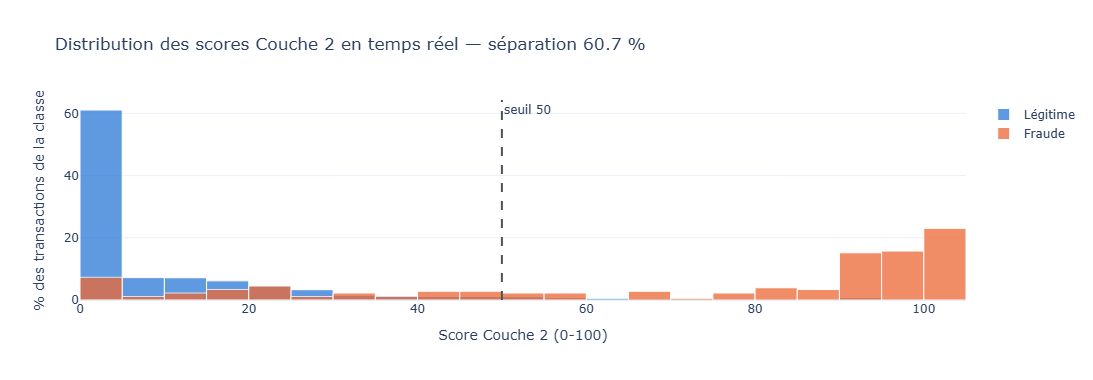

In [12]:
display(tableau_seuils(y_rt, rt["score_c2"]))
histo_scores(y_rt, rt["score_c2"],
             f"Distribution des scores Couche 2 en temps réel — séparation {met_c2['Séparation (pts)']:.1f} %")

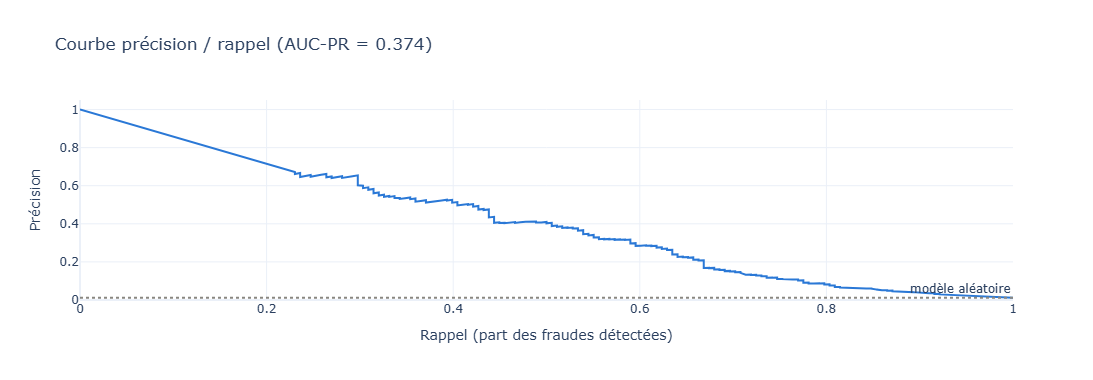

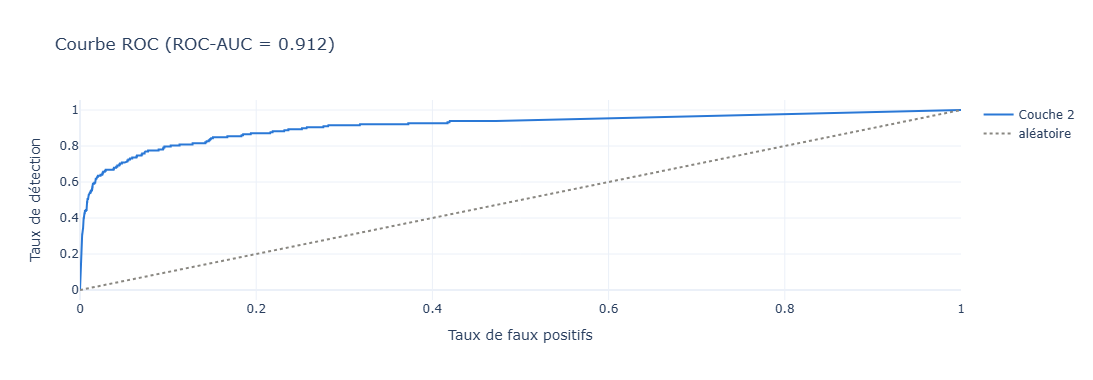

In [13]:
prec, rec, _ = precision_recall_curve(y_rt, rt["score_c2"])
fpr, tpr, _ = roc_curve(y_rt, rt["score_c2"])

fig = go.Figure()
fig.add_scatter(x=rec, y=prec, mode="lines", name="Couche 2", line=dict(color=COULEUR["Légitime"], width=2))
fig.add_hline(y=y_rt.mean(), line_dash="dot", line_color="#898781", annotation_text="modèle aléatoire")
fig.update_layout(title=f"Courbe précision / rappel (AUC-PR = {met_c2['AUC-PR']:.3f})", height=380,
                  template="plotly_white", xaxis_title="Rappel (part des fraudes détectées)",
                  yaxis_title="Précision", yaxis_range=[0, 1.05])
fig.show()

fig = go.Figure()
fig.add_scatter(x=fpr, y=tpr, mode="lines", name="Couche 2", line=dict(color=COULEUR["Légitime"], width=2))
fig.add_scatter(x=[0, 1], y=[0, 1], mode="lines", name="aléatoire", line=dict(color="#898781", dash="dot"))
fig.update_layout(title=f"Courbe ROC (ROC-AUC = {met_c2['ROC-AUC']:.3f})", height=380, template="plotly_white",
                  xaxis_title="Taux de faux positifs", yaxis_title="Taux de détection")
fig.show()

### Résultats par type de scénario
- Pour les **fraudes** : quelle part de chaque type est détectée ?
- Pour les **légitimes** : quelle part est signalée à tort ? On s'attend à davantage d'alertes sur les scénarios atypiques.

In [14]:
par_scen = rt.groupby(["fraude", "scénario"]).agg(
    transactions=("score_c2", "size"),
    score_moyen=("score_c2", "mean"),
    alertes_seuil_50=("score_c2", lambda s: (s >= SEUIL_ALERTE).mean()),
).round(2)
par_scen["alertes_seuil_50"] = par_scen["alertes_seuil_50"].map("{:.1%}".format)
par_scen.index = par_scen.index.set_levels(["Légitime", "Fraude"], level=0)
display(par_scen)

transactions  score_moyen alertes_seuil_50
fraude   scénario                                                           
Légitime GROS_MONTANT_LEGITIME               3        10.86             0.0%
         NORMAL                          14749        10.21             5.0%
         NOUVEAU_DEVICE_LEGITIME            15        38.03            27.0%
         SWAP_LEGITIME                     110        59.01            62.0%
         VOYAGE_LEGITIME                   575         7.31             3.0%
Fraude   PIC_OTP                            10        91.82           100.0%
         SIM_SWAP_CASCADE                  121        85.48            88.0%
         SIM_SWAP_DISCRET                    9        37.49            22.0%
         SIM_SWAP_SIMPLE                    18        45.86            39.0%
         VOL_TELEPHONE                      20        12.07             5.0%

### Décisions si la Couche 2 décidait seule
PASS (< 30) : transaction acceptée · CHALLENGE (30-70) : OTP supplémentaire · BLOCK (≥ 70) : transaction bloquée.

In [15]:
def decisions(s):
    return pd.cut(s, [-1, SEUIL_PASS - 0.5, SEUIL_BLOCK - 0.5, 101], labels=["PASS", "CHALLENGE", "BLOCK"])
dec = pd.crosstab(decisions(rt["score_c2"]), rt["fraude"].map({0: "Légitime", 1: "Fraude"}))
dec["% des fraudes"]   = (dec["Fraude"] / dec["Fraude"].sum()).map("{:.1%}".format)
dec["% des légitimes"] = (dec["Légitime"] / dec["Légitime"].sum()).map("{:.1%}".format)
display(dec)

fraude,Fraude,Légitime,% des fraudes,% des légitimes
score_c2,,,,
PASS,35,13772,19.7%,89.1%
CHALLENGE,28,1286,15.7%,8.3%
BLOCK,115,394,64.6%,2.5%


---
## 7. z-scores par abonné et garde-fou interprétable (exigence 2)

### Principe
Pour chaque transaction, on compare **à l'historique de l'abonné lui-même** (moyenne et écart-type mis à jour en continu, algorithme de Welford) :

| Dimension | Valeur observée | Référence de l'abonné |
|---|---|---|
| `montant` | montant de la transaction | montant moyen ± écart-type |
| `vitesse_24h` | nb de transactions sur 24 h | nb habituel sur 24 h ± écart-type |
| `otp_24h` | nb d'OTP reçus sur 24 h | nb habituel sur 24 h ± écart-type |

Une dimension n'est prise en compte qu'à partir de **10 transactions d'historique**. En dessous, la moyenne n'est pas fiable.

### Règles appliquées
- **z ≥ 3σ** : la dimension est citée dans les **raisons**, en clair. Le score n'est pas modifié.
- **z ≥ 5σ** : **garde-fou**, le score est relevé à **50** minimum. La transaction passe en *CHALLENGE* (OTP supplémentaire).
  Le garde-fou ne **bloque jamais seul** : le blocage (≥ 70) reste une décision du modèle.

### Exemple : ce que voit un analyste
Voici quelques fraudes du test avec leurs z-scores et leurs raisons. C'est la partie **interprétable** : pas besoin de comprendre l'Isolation Forest pour savoir *pourquoi* une transaction est suspecte.

In [16]:
cols = ["scénario", "montant", "historique_tx", "score_if", "score", "zscores", "raisons"]
exemples = rt[(rt["fraude"] == 1) & (rt["raisons"].str.len() > 0)]
display(exemples.sort_values("z_max", ascending=False)[cols].head(8))
fa = rt[(rt["fraude"] == 0) & (rt["raisons"].str.len() > 0)]
print(f"Pour être transparent : {len(fa)} transactions légitimes ont aussi au moins une raison z ≥ {Z_OVERRIDE_SOFT:g}σ "
      f"({len(fa) / max(int((rt['fraude'] == 0).sum()), 1):.1%} des légitimes). Exemples :")
display(fa.sort_values("z_max", ascending=False)[cols].head(5))

,scénario,montant,historique_tx,score_if,score,zscores,raisons
9126,VOL_TELEPHONE,7554.29,16,25.77,50,"{'montant': 13.23, 'vitesse_24h': 0.19, 'otp_24h': -0.62}","[garde-fou z-score (≥ 5σ) : score relevé de 26 à 50, montant : +13.2σ (observé 7554.29, habituel 1721.9 ± 440.9)]"
10774,PIC_OTP,66340.22,29,92.97,93,"{'montant': 0.97, 'vitesse_24h': 1.4, 'otp_24h': 10.03}","[otp_24h : +10.0σ (observé 11, habituel 1.0 ± 1.0)]"
8074,PIC_OTP,146199.66,24,95.48,95,"{'montant': -0.72, 'vitesse_24h': -1.02, 'otp_24h': 9.33}","[otp_24h : +9.3σ (observé 10, habituel 0.7 ± 1.0)]"
8780,PIC_OTP,63567.00,14,93.74,94,"{'montant': 1.51, 'vitesse_24h': 0.78, 'otp_24h': 8.57}","[otp_24h : +8.6σ (observé 9, habituel 0.4 ± 1.0)]"
1832,PIC_OTP,8311.87,15,100.00,100,"{'montant': 3.11, 'vitesse_24h': 1.34, 'otp_24h': 7.53}","[montant : +3.1σ (observé 8311.87, habituel 2817.1 ± 1766.9), otp_24h : +7.5σ (observé 8, habituel 0.5 ± 1.0)]"
7261,PIC_OTP,7125.82,27,91.87,92,"{'montant': -0.83, 'vitesse_24h': 1.52, 'otp_24h': 6.93}","[otp_24h : +6.9σ (observé 8, habituel 1.1 ± 1.0)]"
8692,PIC_OTP,2205.26,18,90.66,91,"{'montant': 0.03, 'vitesse_24h': -0.28, 'otp_24h': 6.56}","[otp_24h : +6.6σ (observé 7, habituel 0.4 ± 1.0)]"
13566,PIC_OTP,34775.29,55,66.70,67,"{'montant': 0.01, 'vitesse_24h': 1.2, 'otp_24h': 6.53}","[otp_24h : +6.5σ (observé 12, habituel 1.3 ± 1.6)]"


Pour être transparent : 519 transactions légitimes ont aussi au moins une raison z ≥ 3σ (3.4% des légitimes). Exemples :


,scénario,montant,historique_tx,score_if,score,zscores,raisons
12551,NORMAL,9138.27,23,29.95,50,"{'montant': 85.53, 'vitesse_24h': -0.85, 'otp_24h': 0.13}","[garde-fou z-score (≥ 5σ) : score relevé de 30 à 50, montant : +85.5σ (observé 9138.27, habituel 600.5 ± 99.8)]"
1742,NORMAL,22928.91,14,40.14,50,"{'montant': 36.97, 'vitesse_24h': 0.96, 'otp_24h': 1.07}","[garde-fou z-score (≥ 5σ) : score relevé de 40 à 50, montant : +37.0σ (observé 22928.9, habituel 857.4 ± 597.0)]"
3665,NORMAL,112017.81,12,28.95,50,"{'montant': 23.56, 'vitesse_24h': 2.24, 'otp_24h': 0.75}","[garde-fou z-score (≥ 5σ) : score relevé de 29 à 50, montant : +23.6σ (observé 112018, habituel 9657.9 ± 4344.5)]"
11582,NORMAL,18313.92,41,26.83,50,"{'montant': 17.99, 'vitesse_24h': 0.05, 'otp_24h': -0.16}","[garde-fou z-score (≥ 5σ) : score relevé de 27 à 50, montant : +18.0σ (observé 18313.9, habituel 1509.8 ± 934.2)]"
6735,NORMAL,21503.35,16,13.64,50,"{'montant': 9.94, 'vitesse_24h': -1.36, 'otp_24h': -0.88}","[garde-fou z-score (≥ 5σ) : score relevé de 14 à 50, montant : +9.9σ (observé 21503.3, habituel 5314.5 ± 1628.0)]"


### Apport du garde-fou : IF seul vs IF + garde-fou
Même trafic, mêmes transactions. Seule la règle du garde-fou change.

In [17]:
met_rt_if = metriques(y_rt, rt["score_if"])
comp = pd.DataFrame({"IF seul": met_rt_if, "IF + garde-fou z-score": met_c2}).round(3)
comp["écart"] = (comp["IF + garde-fou z-score"] - comp["IF seul"]).round(3)
display(comp)

# garde_fou = True quand le z-score a effectivement relevé un score IF < 50
rattrapees = int((rt["garde_fou"] & (rt["fraude"] == 1)).sum())
fausses    = int((rt["garde_fou"] & (rt["fraude"] == 0)).sum())
z_extreme_fraude = int(((rt["z_max"] >= Z_OVERRIDE_HARD) & (rt["fraude"] == 1)).sum())
print(f"Transactions avec un z-score ≥ {Z_OVERRIDE_HARD:g}σ : {int((rt['z_max'] >= Z_OVERRIDE_HARD).sum())} "
      f"(dont {z_extreme_fraude} fraudes)")
print(f"Garde-fou ayant relevé le score (IF < {Z_GUARD_FLOOR:.0f}) : {rattrapees + fausses} fois")
print(f"  → fraudes rattrapées que l'IF seul laissait passer : {rattrapees}")
print(f"  → fausses alertes supplémentaires                  : {fausses}")

if rattrapees + fausses == 0:
    interpretation = (
        f"**Lecture** : sur ce jeu de test, chaque transaction à z ≥ {Z_OVERRIDE_HARD:g}σ avait **déjà** un score IF ≥ "
        f"{Z_GUARD_FLOOR:.0f}. L'Isolation Forest capte donc lui-même ces écarts extrêmes, et le garde-fou n'a rien eu à "
        "relever. Il ne dégrade pas les performances (aucune fausse alerte ajoutée). Sa valeur est ailleurs : "
        "**expliquer** les alertes (raisons ci-dessus), **servir de filet** si le modèle se trompe sur un cas "
        "imprévu, et **prendre le relais** si le modèle est indisponible (voir ci-dessous).")
else:
    interpretation = (
        f"**Lecture** : le garde-fou a relevé le score de {rattrapees + fausses} transaction(s) que l'IF jugeait "
        f"peu suspecte(s) : {rattrapees} fraude(s) rattrapée(s), {fausses} fausse(s) alerte(s) ajoutée(s). Comparez les deux colonnes "
        "du tableau pour décider si ce compromis est acceptable (seuil réglable, voir la sensibilité ci-dessous).")
display(Markdown(interpretation))

CONTROLES["2a. z-scores par abonné calculés pour chaque transaction"] = rt["zscores"].map(len).gt(0).mean() > 0.5
CONTROLES["2b. Raisons lisibles produites pour les z-scores anormaux"] = rt["raisons"].map(len).gt(0).any()
# Les z-scores affichés sont arrondis à 2 décimales : un z de 4,996 apparaît « 5,00 » alors que
# le détecteur (valeur exacte) n'applique pas le garde-fou. On ignore donc cette marge d'arrondi.
violations = rt[(rt["z_max"] >= Z_OVERRIDE_HARD + 0.005) & (rt["score"] < Z_GUARD_FLOOR)]
arrondis = rt[(rt["z_max"] >= Z_OVERRIDE_HARD) & (rt["z_max"] < Z_OVERRIDE_HARD + 0.005) & (rt["score"] < Z_GUARD_FLOOR)]
print(f"Contrôle du garde-fou : {len(violations)} violation(s) réelle(s), "
      f"{len(arrondis)} cas à la limite d'arrondi (z affiché 5,00, valeur exacte < 5)")
if len(violations):
    display(violations[["scénario", "historique_tx", "score_if", "score", "zscores"]].head())
CONTROLES["2c. Garde-fou actif (relève le score si z ≥ 5σ)"] = len(violations) == 0

,IF seul,IF + garde-fou z-score,écart
AUC-PR,0.374,0.374,0.000
ROC-AUC,0.912,0.912,0.000
Rappel @1% FPR,0.528,0.528,0.000
Rappel @5% FPR,0.708,0.708,0.000
Rappel @ seuil 50,0.708,0.713,0.005
FPR @ seuil 50,0.051,0.054,0.003
Précision @ seuil 50,0.139,0.133,-0.006
Score moyen fraudes,71.021,71.157,0.136
Score moyen légitimes,10.395,10.475,0.080
Séparation (pts),60.626,60.682,0.056


Transactions avec un z-score ≥ 5σ : 72 (dont 9 fraudes)
Garde-fou ayant relevé le score (IF < 50) : 45 fois
  → fraudes rattrapées que l'IF seul laissait passer : 1
  → fausses alertes supplémentaires                  : 44


**Lecture** : le garde-fou a relevé le score de 45 transaction(s) que l'IF jugeait peu suspecte(s) : 1 fraude(s) rattrapée(s), 44 fausse(s) alerte(s) ajoutée(s). Comparez les deux colonnes du tableau pour décider si ce compromis est acceptable (seuil réglable, voir la sensibilité ci-dessous).

Contrôle du garde-fou : 0 violation(s) réelle(s), 1 cas à la limite d'arrondi (z affiché 5,00, valeur exacte < 5)


### Sensibilité : à partir de quel z-score déclencher le garde-fou ?
Le seuil (5σ par défaut) se règle avec la variable d'environnement `Z_OVERRIDE_HARD`.
Ce tableau montre l'effet de différents seuils, recalculé à partir des mêmes z-scores.

In [ ]:
lignes_sens = []
for h in [None, 3, 4, 5, 6, 8]:
    s = rt["score_if"].values if h is None else np.where(
        (rt["z_max"] >= h) & (rt["score_if"] < Z_GUARD_FLOOR), Z_GUARD_FLOOR, rt["score_if"])
    mm = metriques(y_rt, s)
    lignes_sens.append({"seuil garde-fou": "aucun (IF seul)" if h is None else f"z ≥ {h}σ",
                        "Rappel @ seuil 50": f"{mm['Rappel @ seuil 50']:.1%}",
                        "FPR @ seuil 50": f"{mm['FPR @ seuil 50']:.2%}",
                        "Précision @ seuil 50": f"{mm['Précision @ seuil 50']:.1%}",
                        "Séparation": f"{mm['Séparation (pts)']:.1f} %",
                        "AUC-PR": round(mm["AUC-PR"], 3)})
display(pd.DataFrame(lignes_sens).set_index("seuil garde-fou"))

### Scénario de panne : modèle IF indisponible
Si le modèle ne peut pas être chargé (S3 inaccessible, fichier corrompu…), le détecteur passe en **mode dégradé**.
Le score est alors calculé **uniquement à partir des z-scores par abonné** : 3σ → 75, 5σ → 90, 8σ → 100.
Voici ce que la Couche 2 détecterait dans ce cas, sur les mêmes transactions de test.

In [ ]:
detecteur_panne = AnomalyDetector(store=MemStore())   # stockage vide → aucun modèle
print("Mode du détecteur :", detecteur_panne.version)
score_panne = np.array([detecteur_panne._score_from_zscore(z) if h > 0 else 0.0
                        for z, h in zip(rt["z_max"], rt["historique_tx"])])
display(pd.DataFrame({"IF + garde-fou (normal)": met_c2,
                      "z-scores seuls (mode dégradé)": metriques(y_rt, score_panne)}).round(3))
CONTROLES["2d. Mode dégradé : les z-scores prennent le relais"] = (
    detecteur_panne.version == "degraded" and score_panne.max() > 0)

In [ ]:
# Quelle dimension signale le mieux la fraude ?
z_long = pd.DataFrame([{"dimension": d, "z": z, "fraude": f}
                       for zs, f in zip(rt["zscores"], rt["fraude"]) for d, z in zs.items()])
par_dim = z_long.groupby(["dimension", "fraude"])["z"].agg(
    médiane="median", part_z_sup_3=lambda z: (z >= Z_OVERRIDE_SOFT).mean(),
    part_z_sup_5=lambda z: (z >= Z_OVERRIDE_HARD).mean()).round(3)
par_dim.index = par_dim.index.set_levels(["Légitime", "Fraude"], level=1)
display(par_dim)

---
## 8. Latence et cas limites

In [ ]:
echantillon = [ev for ev in all_events if ev["stream"] == "transactions"][:500]
lat = []
for ev in echantillon:
    t = time.perf_counter()
    detector.predict(ev, profils.get(ev["id_compte"], {}))
    lat.append((time.perf_counter() - t) * 1000)
print(f"Latence predict() : moyenne {np.mean(lat):.2f} ms | p95 {np.percentile(lat, 95):.2f} ms | max {np.max(lat):.2f} ms")

ok_vide = detector.score_if_degraded()
print(f"Compte sans historique → score 0 : {'✅' if ok_vide else '❌'}")
froids = rt["historique_tx"] < Z_MIN_TRANSACTIONS
print(f"Transactions de test avec moins de {Z_MIN_TRANSACTIONS} tx d'historique (z-scores inactifs) : "
      f"{froids.mean():.1%}")
CONTROLES["Compte sans historique → score 0"] = ok_vide

---
## 9. Récapitulatif

In [ ]:
print("=" * 70)
print("  CONFORMITÉ IA-5")
print("=" * 70)
for k, v in CONTROLES.items():
    print(f"  {'✅' if v else '❌'} {k}")
print()
print("  PERFORMANCES EN TEMPS RÉEL SUR LE TEST (abonnés jamais vus)")
display(tableau_metriques(met_c2, y_rt))
print(f"  Modèle : {res.model_key}  (version {res.version})")
print(f"  Verdict global : {'CONFORME ✅' if all(CONTROLES.values()) else 'À CORRIGER ❌'}")

### Limites connues, à garder en tête
- **Non supervisé = rappel limité à faible taux d'alerte.** L'IF ne connaît que le « normal ». Il signale l'inhabituel, pas forcément la fraude. C'est la Couche 3 (XGBoost supervisé) qui porte l'essentiel de la précision.
- **Les features constantes sur le trafic légitime** (voir section 2) sont inutilisables par l'IF. Les z-scores et les règles (Couche 1) couvrent ces signaux.
- **Comptes récents** (< 10 transactions) : les z-scores sont inactifs, faute d'historique fiable. Un compte sans aucune transaction reçoit 0.
- **Données simulées** : les performances devront être revalidées sur du trafic réel avant la production.

### Réglages disponibles (variables d'environnement)
| Variable | Défaut | Effet |
|---|---|---|
| `Z_GUARD_ENABLED` | `1` | active / désactive le garde-fou en mode normal |
| `Z_OVERRIDE_HARD` | `5.0` | z-score qui déclenche le garde-fou |
| `Z_GUARD_FLOOR` | `50` | score plancher imposé par le garde-fou |
| `Z_OVERRIDE_SOFT` | `3.0` | z-score à partir duquel une raison est affichée |
| `Z_MIN_TRANSACTIONS` | `10` | historique minimal pour faire confiance aux z-scores |